### **Problem statement**
XYZ co's 2014-2018 sales data to identify key revenue and profit drivers across products, channels, and regions, uncover sesonal trends and outliers, and align performance against budgets. Use these insights to optimize pricing, promotions and market expantion for sustainable growth and reduced concentration risk.

In [1]:
# Importing libraries

import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [2]:
Sheets = pd.read_excel('Regional Sales Dataset.xlsx', sheet_name=None)

In [3]:
Sheets

{'Sales Orders':         OrderNumber  OrderDate  Customer Name Index      Channel  \
 0       SO - 000225 2014-01-01                  126    Wholesale   
 1      SO - 0003378 2014-01-01                   96  Distributor   
 2      SO - 0005126 2014-01-01                    8    Wholesale   
 3      SO - 0005614 2014-01-01                   42       Export   
 4      SO - 0005781 2014-01-01                   73    Wholesale   
 ...             ...        ...                  ...          ...   
 64099  SO - 0007573 2018-02-28                   74    Wholesale   
 64100  SO - 0007706 2018-02-28                   51       Export   
 64101  SO - 0007718 2018-02-28                  136  Distributor   
 64102  SO - 0008084 2018-02-28                  158  Distributor   
 64103  SO - 0008654 2018-02-28                   22  Distributor   
 
       Currency Code Warehouse Code  Delivery Region Index  \
 0               USD         AXW291                    364   
 1               USD         A

In [4]:
# Assign Dataframe to each sheets 
df_sales = Sheets['Sales Orders']
df_customers= Sheets['Customers']
df_regions = Sheets['Regions']
df_state_reg = Sheets['State Regions']
df_products= Sheets['Products']
df_budgets= Sheets['2017 Budgets']

In [5]:
df_sales.head()

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,Line Total,Total Unit Cost
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,14994.6,1824.343
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,25868.7,1269.918
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,5869.2,684.740
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,16368.1,1028.852
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,18331.2,1260.270


In [6]:
df_sales.shape

(64104, 12)

In [7]:
print(f"df_sales shape: {df_sales.shape}")
print(f"df_customers shape: {df_customers.shape}") 
print(f"df_regions shape: {df_regions.shape}") 
print(f"df_state_reg shape: {df_state_reg.shape}") 
print(f"df_products shape: {df_products.shape}") 
print(f"df_budgets shape: {df_budgets.shape}") 

df_sales shape: (64104, 12)
df_customers shape: (175, 2)
df_regions shape: (994, 15)
df_state_reg shape: (49, 3)
df_products shape: (30, 2)
df_budgets shape: (30, 2)


In [8]:
df_customers.head()

,Customer Index,Customer Names
0,1,Geiss Company
1,2,Jaxbean Group
2,3,Ascend Ltd
3,4,Eire Corp
4,5,Blogtags Ltd


In [9]:
df_regions.head()

,id,name,county,state_code,state,type,latitude,longitude,area_code,population,households,median_income,land_area,water_area,time_zone
0,1,Auburn,Lee County,AL,Alabama,City,32.60986,-85.48078,334,62059,21767,38342,152375113,2646161,America/Chicago
1,2,Birmingham,Shelby County/Jefferson County,AL,Alabama,City,33.52744,-86.79905,205,212461,89972,31061,378353942,6591013,America/Chicago
2,3,Decatur,Limestone County/Morgan County,AL,Alabama,City,34.57332,-86.99214,256,55437,22294,41496,141006257,17594716,America/Chicago
3,4,Dothan,Dale County/Houston County/Henry County,AL,Alabama,City,31.23370,-85.40682,334,68567,25913,42426,232166237,835468,America/Chicago
4,5,Hoover,Shelby County/Jefferson County,AL,Alabama,City,33.37695,-86.80558,205,84848,32789,77146,122016784,2553332,America/Chicago


In [10]:
df_state_reg.head()

,Column1,Column2,Column3
0,State Code,State,Region
1,AL,Alabama,South
2,AR,Arkansas,South
3,AZ,Arizona,West
4,CA,California,West


In [11]:
new_header = df_state_reg.iloc[0]
df_state_reg.columns= new_header
df_state_reg= df_state_reg[1:].reset_index(drop=True)
df_state_reg.head()

,State Code,State,Region
0,AL,Alabama,South
1,AR,Arkansas,South
2,AZ,Arizona,West
3,CA,California,West
4,CO,Colorado,West


In [12]:
df_products.head()

,Index,Product Name
0,1,Product 1
1,2,Product 2
2,3,Product 3
3,4,Product 4
4,5,Product 5


In [13]:
df_budgets.head()

,Product Name,2017 Budgets
0,Product 1,3016489.209
1,Product 2,3050087.565
2,Product 3,2642352.432
3,Product 4,2885560.824
4,Product 5,3925424.542


In [14]:
df_sales.isnull().sum()

OrderNumber                  0
OrderDate                    0
Customer Name Index          0
Channel                      0
Currency Code                0
Warehouse Code               0
Delivery Region Index        0
Product Description Index    0
Order Quantity               0
Unit Price                   0
Line Total                   0
Total Unit Cost              0
dtype: int64

In [15]:
df_customers.isnull().sum()

Customer Index    0
Customer Names    0
dtype: int64

In [16]:
df_state_reg.isnull().sum()

0
State Code    0
State         0
Region        0
dtype: int64

In [17]:
df_regions.isnull().sum()

id               0
name             0
county           0
state_code       0
state            0
type             0
latitude         0
longitude        0
area_code        0
population       0
households       0
median_income    0
land_area        0
water_area       0
time_zone        0
dtype: int64

In [18]:
df_products.isnull().sum()

Index           0
Product Name    0
dtype: int64

In [19]:
df_budgets.isnull().sum()

Product Name    0
2017 Budgets    0
dtype: int64

In [20]:
# Merge with customers

df = df_sales.merge(
    df_customers,
    how='left', 
    left_on='Customer Name Index', 
    right_on='Customer Index'
)

In [21]:
df.head()

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,Line Total,Total Unit Cost,Customer Index,Customer Names
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,14994.6,1824.343,126,Rhynoodle Ltd
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,25868.7,1269.918,96,Thoughtmix Ltd
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,5869.2,684.740,8,Amerisourc Corp
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,16368.1,1028.852,42,Colgate-Pa Group
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,18331.2,1260.270,73,Deseret Group


In [22]:
# Marge with products 

df= df.merge(
    df_products,
    how='left',
    left_on='Product Description Index',
    right_on='Index'
)

In [23]:
df.head()

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,Line Total,Total Unit Cost,Customer Index,Customer Names,Index,Product Name
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,14994.6,1824.343,126,Rhynoodle Ltd,27,Product 27
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,25868.7,1269.918,96,Thoughtmix Ltd,20,Product 20
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,5869.2,684.740,8,Amerisourc Corp,26,Product 26
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,16368.1,1028.852,42,Colgate-Pa Group,7,Product 7
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,18331.2,1260.270,73,Deseret Group,8,Product 8


In [24]:
# merge with regions 

df= df.merge(
    df_regions,
    how='left',
    left_on='Delivery Region Index', 
    right_on='id'
)

In [25]:
df.head()

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,...,type,latitude,longitude,area_code,population,households,median_income,land_area,water_area,time_zone
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,...,City,32.08354,-81.09983,912,145674,52798,36466,268318796,13908113,America/New York
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,...,City,39.61366,-86.10665,317,55586,20975,54176,72276415,1883,America/Indiana/Indianapolis
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,...,City,37.66243,-121.87468,925,79510,26020,124759,62489257,386195,America/Los Angeles
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,...,City,39.16533,-86.52639,812,84067,30232,30019,60221613,475857,America/Indiana/Indianapolis
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,...,Town,41.77524,-72.52443,959,58007,24141,63158,70972793,720300,America/New York


In [26]:
# merge with df_state_reg

df= df.merge(
    df_state_reg[['State Code','Region']],
    how='left',
    left_on='state_code', 
    right_on='State Code'
)

In [27]:
df.head()

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,...,longitude,area_code,population,households,median_income,land_area,water_area,time_zone,State Code,Region
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,...,-81.09983,912,145674,52798,36466,268318796,13908113,America/New York,GA,South
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,...,-86.10665,317,55586,20975,54176,72276415,1883,America/Indiana/Indianapolis,IN,Midwest
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,...,-121.87468,925,79510,26020,124759,62489257,386195,America/Los Angeles,CA,West
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,...,-86.52639,812,84067,30232,30019,60221613,475857,America/Indiana/Indianapolis,IN,Midwest
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,...,-72.52443,959,58007,24141,63158,70972793,720300,America/New York,CT,Northeast


In [28]:
# merge with df_budgets

df= df.merge(
    df_budgets,
    how='left',
    on = 'Product Name'
)

In [29]:
df.head()

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,...,area_code,population,households,median_income,land_area,water_area,time_zone,State Code,Region,2017 Budgets
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,...,912,145674,52798,36466,268318796,13908113,America/New York,GA,South,964940.231
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,...,317,55586,20975,54176,72276415,1883,America/Indiana/Indianapolis,IN,Midwest,2067108.120
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,...,925,79510,26020,124759,62489257,386195,America/Los Angeles,CA,West,5685138.270
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,...,812,84067,30232,30019,60221613,475857,America/Indiana/Indianapolis,IN,Midwest,889737.555
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,...,959,58007,24141,63158,70972793,720300,America/New York,CT,Northeast,1085037.329


In [31]:
df.to_csv('file_1.csv')

In [32]:
# Customer Index 
# Index 
# id
# State Code

# Clean up redundant columns 
cols_to_drop = ['Customer Index','Index','id','State Code']
df= df.drop(columns=cols_to_drop, errors='ignore')

df.head()

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,...,longitude,area_code,population,households,median_income,land_area,water_area,time_zone,Region,2017 Budgets
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,...,-81.09983,912,145674,52798,36466,268318796,13908113,America/New York,South,964940.231
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,...,-86.10665,317,55586,20975,54176,72276415,1883,America/Indiana/Indianapolis,Midwest,2067108.120
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,...,-121.87468,925,79510,26020,124759,62489257,386195,America/Los Angeles,West,5685138.270
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,...,-86.52639,812,84067,30232,30019,60221613,475857,America/Indiana/Indianapolis,Midwest,889737.555
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,...,-72.52443,959,58007,24141,63158,70972793,720300,America/New York,Northeast,1085037.329


In [33]:
# Convert all the columns to lower case for consistency and easier access 

df.columns = df.columns.str.lower()

df.columns.values

array(['ordernumber', 'orderdate', 'customer name index', 'channel',
       'currency code', 'warehouse code', 'delivery region index',
       'product description index', 'order quantity', 'unit price',
       'line total', 'total unit cost', 'customer names', 'product name',
       'name', 'county', 'state_code', 'state', 'type', 'latitude',
       'longitude', 'area_code', 'population', 'households',
       'median_income', 'land_area', 'water_area', 'time_zone', 'region',
       '2017 budgets'], dtype=object)

In [34]:
# Keep the important columns and delete the columns that we don't need 

cols_to_keep =[
    'ordernumber', 
    'orderdate', 
    'customer names', 
    'channel', 
    'product name', 
    'order quantity', 
    'unit price', 
    'line total', 
    'total unit cost', 
    'state_code', 
    'county', 
    'state', 
    'region', 
    'latitude', 
    'longitude', 
    '2017 budgets'
]

In [35]:
df= df[cols_to_keep]

In [36]:
df.head()

,ordernumber,orderdate,customer names,channel,product name,order quantity,unit price,line total,total unit cost,state_code,county,state,region,latitude,longitude,2017 budgets
0,SO - 000225,2014-01-01,Rhynoodle Ltd,Wholesale,Product 27,6,2499.1,14994.6,1824.343,GA,Chatham County,Georgia,South,32.08354,-81.09983,964940.231
1,SO - 0003378,2014-01-01,Thoughtmix Ltd,Distributor,Product 20,11,2351.7,25868.7,1269.918,IN,Johnson County,Indiana,Midwest,39.61366,-86.10665,2067108.120
2,SO - 0005126,2014-01-01,Amerisourc Corp,Wholesale,Product 26,6,978.2,5869.2,684.740,CA,Alameda County,California,West,37.66243,-121.87468,5685138.270
3,SO - 0005614,2014-01-01,Colgate-Pa Group,Export,Product 7,7,2338.3,16368.1,1028.852,IN,Monroe County,Indiana,Midwest,39.16533,-86.52639,889737.555
4,SO - 0005781,2014-01-01,Deseret Group,Wholesale,Product 8,8,2291.4,18331.2,1260.270,CT,Hartford County,Connecticut,Northeast,41.77524,-72.52443,1085037.329


In [37]:
# Rename the columns 

df = df.rename(columns={
    'ordernumber':'order_number', 
    'orderdate':'order_date', 
    'customer names':'customer_names',  
    'product name':'product_name', 
    'order quantity':'order_quantity', 
    'unit price':'unit_price', 
    'line total':'revenue', 
    'total unit cost':'cost', 
    'state_code':'state', 
    'state':'state_name', 
    'latitude':'lat',
    'longitude':'lon',
    '2017 budgets':'budget'
})

In [38]:
# Blank out budgets for non_2017 orders
df.loc[df['order_date'].dt.year !=2017,'budget']= pd.NA 

df[['order_date','product_name','revenue','budget']]

,order_date,product_name,revenue,budget
0,2014-01-01,Product 27,14994.6,NaN
1,2014-01-01,Product 20,25868.7,NaN
2,2014-01-01,Product 26,5869.2,NaN
3,2014-01-01,Product 7,16368.1,NaN
4,2014-01-01,Product 8,18331.2,NaN
...,...,...,...,...
64099,2018-02-28,Product 26,21788.4,NaN
64100,2018-02-28,Product 21,5185.8,NaN
64101,2018-02-28,Product 13,43483.0,NaN
64102,2018-02-28,Product 20,27717.9,NaN


In [40]:
df.to_csv('file_2.csv')

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64104 entries, 0 to 64103
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_number    64104 non-null  object        
 1   order_date      64104 non-null  datetime64[ns]
 2   customer_names  64104 non-null  object        
 3   channel         64104 non-null  object        
 4   product_name    64104 non-null  object        
 5   order_quantity  64104 non-null  int64         
 6   unit_price      64104 non-null  float64       
 7   revenue         64104 non-null  float64       
 8   cost            64104 non-null  float64       
 9   state           64104 non-null  object        
 10  county          64104 non-null  object        
 11  state_name      64104 non-null  object        
 12  region          64104 non-null  object        
 13  lat             64104 non-null  float64       
 14  lon             64104 non-null  float64       
 15  bu

In [42]:
# Filter the dataset to include only records from year 2017

df_2017= df[df['order_date'].dt.year == 2017]

In [43]:
df_2017.head()

,order_number,order_date,customer_names,channel,product_name,order_quantity,unit_price,revenue,cost,state,county,state_name,region,lat,lon,budget
46363,SO - 0002544,2017-01-01,NCS Group,Wholesale,Product 30,6,1239.5,7437.0,1028.785,NJ,Hudson County,New Jersey,Northeast,40.77955,-74.02375,1011609.684
46364,SO - 0006431,2017-01-01,Epic Group,Wholesale,Product 13,5,1829.1,9145.5,1207.206,CO,Mesa County,Colorado,West,39.06387,-108.55065,3720639.645
46365,SO - 0007491,2017-01-01,State Ltd,Wholesale,Product 15,9,2412.0,21708.0,1664.280,CA,Los Angeles County,California,West,33.96168,-118.35313,3299478.315
46366,SO - 0008741,2017-01-01,Fivebridge Ltd,Wholesale,Product 8,8,904.5,7236.0,750.735,IA,Dubuque County,Iowa,Midwest,42.50056,-90.66457,1085037.329
46367,SO - 0009295,2017-01-01,Tagfeed Ltd,Wholesale,Product 2,12,1112.2,13346.4,811.906,FL,Hernando County,Florida,South,28.47689,-82.52546,3050087.565


In [44]:
df_2017.isnull().sum()

order_number      0
order_date        0
customer_names    0
channel           0
product_name      0
order_quantity    0
unit_price        0
revenue           0
cost              0
state             0
county            0
state_name        0
region            0
lat               0
lon               0
budget            0
dtype: int64

### Feature Engineering

In [45]:
df['total_cost'] = df['order_quantity']*df['cost']

In [46]:
df['profit']=df['revenue']-df['total_cost']
df['profit_margin_pct']= df['profit'] / df['revenue']*100

In [47]:
df.head()

,order_number,order_date,customer_names,channel,product_name,order_quantity,unit_price,revenue,cost,state,county,state_name,region,lat,lon,budget,total_cost,profit,profit_margin_pct
0,SO - 000225,2014-01-01,Rhynoodle Ltd,Wholesale,Product 27,6,2499.1,14994.6,1824.343,GA,Chatham County,Georgia,South,32.08354,-81.09983,NaN,10946.058,4048.542,27.0
1,SO - 0003378,2014-01-01,Thoughtmix Ltd,Distributor,Product 20,11,2351.7,25868.7,1269.918,IN,Johnson County,Indiana,Midwest,39.61366,-86.10665,NaN,13969.098,11899.602,46.0
2,SO - 0005126,2014-01-01,Amerisourc Corp,Wholesale,Product 26,6,978.2,5869.2,684.740,CA,Alameda County,California,West,37.66243,-121.87468,NaN,4108.440,1760.760,30.0
3,SO - 0005614,2014-01-01,Colgate-Pa Group,Export,Product 7,7,2338.3,16368.1,1028.852,IN,Monroe County,Indiana,Midwest,39.16533,-86.52639,NaN,7201.964,9166.136,56.0
4,SO - 0005781,2014-01-01,Deseret Group,Wholesale,Product 8,8,2291.4,18331.2,1260.270,CT,Hartford County,Connecticut,Northeast,41.77524,-72.52443,NaN,10082.160,8249.040,45.0


In [48]:
df.to_csv('file_3.csv')

## EDA

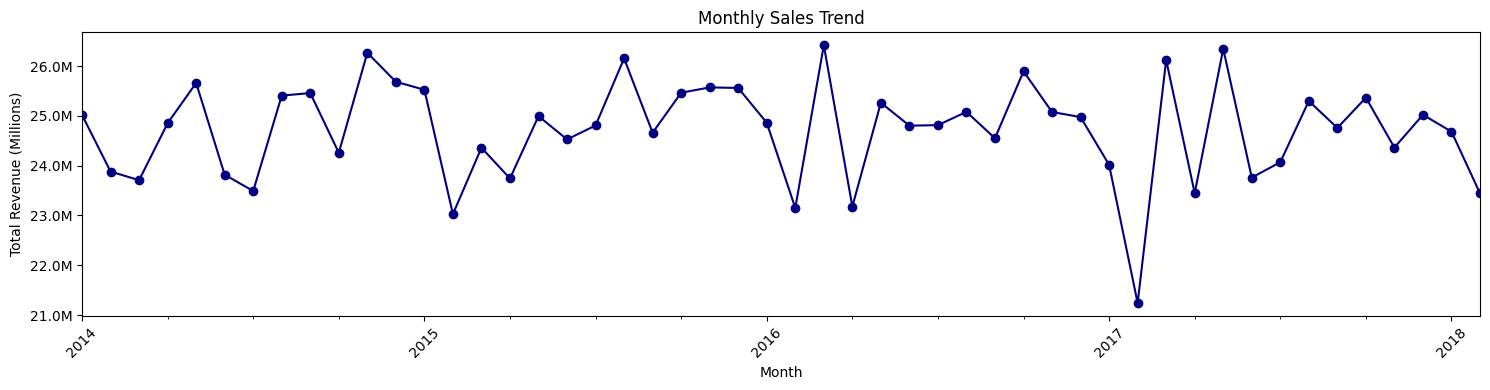

In [49]:
df['order_month']= df['order_date'].dt.to_period('M')

monthly_sales = df.groupby('order_month')['revenue'].sum()

plt.figure(figsize=(15,4))

monthly_sales.plot(marker='o', color='navy')

from matplotlib.ticker import FuncFormatter
formatter = FuncFormatter(lambda x, pos:f'{x/1e6:.1f}M')
plt.gca().yaxis.set_major_formatter(formatter)

plt.title("Monthly Sales Trend")
plt.xlabel('Month')
plt.ylabel('Total Revenue (Millions)')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [50]:
pd.set_option('display.max_columns', None)
df.head()

,order_number,order_date,customer_names,channel,product_name,order_quantity,unit_price,revenue,cost,state,county,state_name,region,lat,lon,budget,total_cost,profit,profit_margin_pct,order_month
0,SO - 000225,2014-01-01,Rhynoodle Ltd,Wholesale,Product 27,6,2499.1,14994.6,1824.343,GA,Chatham County,Georgia,South,32.08354,-81.09983,NaN,10946.058,4048.542,27.0,2014-01
1,SO - 0003378,2014-01-01,Thoughtmix Ltd,Distributor,Product 20,11,2351.7,25868.7,1269.918,IN,Johnson County,Indiana,Midwest,39.61366,-86.10665,NaN,13969.098,11899.602,46.0,2014-01
2,SO - 0005126,2014-01-01,Amerisourc Corp,Wholesale,Product 26,6,978.2,5869.2,684.740,CA,Alameda County,California,West,37.66243,-121.87468,NaN,4108.440,1760.760,30.0,2014-01
3,SO - 0005614,2014-01-01,Colgate-Pa Group,Export,Product 7,7,2338.3,16368.1,1028.852,IN,Monroe County,Indiana,Midwest,39.16533,-86.52639,NaN,7201.964,9166.136,56.0,2014-01
4,SO - 0005781,2014-01-01,Deseret Group,Wholesale,Product 8,8,2291.4,18331.2,1260.270,CT,Hartford County,Connecticut,Northeast,41.77524,-72.52443,NaN,10082.160,8249.040,45.0,2014-01


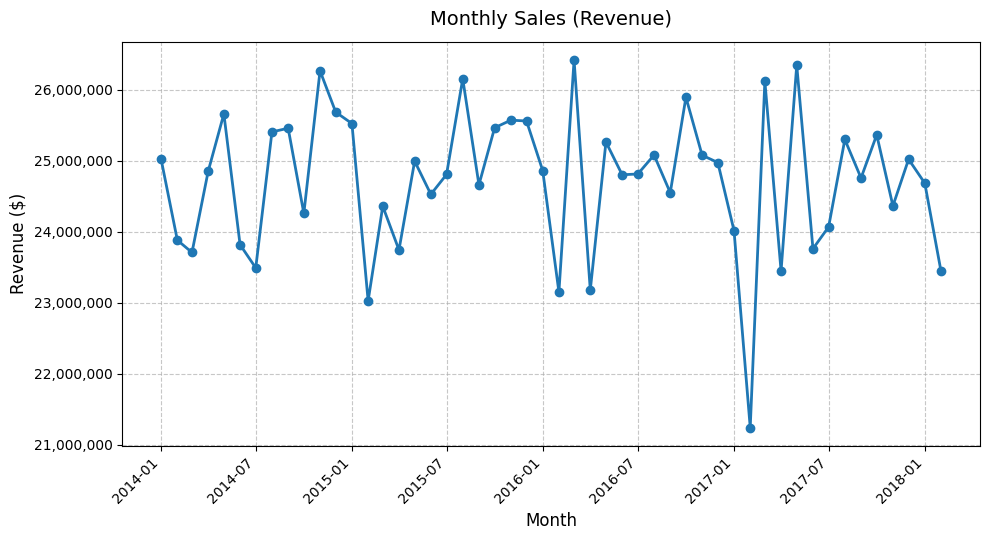

In [51]:
import pandas as pd
import matplotlib.pyplot as plt

# ───────────────────────────────────────────────
# Option 1: Most readable & commonly used approach
# ───────────────────────────────────────────────

# Make sure order_date is datetime
df['order_date'] = pd.to_datetime(df['order_date'])

# Create a proper monthly period (better for grouping)
df['month'] = df['order_date'].dt.to_period('M')

# Aggregate monthly revenue
monthly_sales = df.groupby('month')['revenue'].sum().reset_index()

# Convert period back to datetime for nice plotting
monthly_sales['month'] = monthly_sales['month'].dt.to_timestamp()

# ─── Plot ───────────────────────────────────────
plt.figure(figsize=(10, 5.5))

plt.plot(monthly_sales['month'], 
         monthly_sales['revenue'],
         marker='o',          # shows data points
         linewidth=2,
         color='#1f77b4')     # nice blue

plt.title('Monthly Sales (Revenue)', fontsize=14, pad=12)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Revenue ($)', fontsize=12)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Add grid
plt.grid(True, linestyle='--', alpha=0.7)

# Format y-axis with commas
plt.ticklabel_format(style='plain', axis='y')
# Optional: use comma separator
from matplotlib.ticker import FuncFormatter
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.show()

In [52]:
# See rows that will be removed
df['order_month'] = df['order_month'].astype(str).str.strip()
rows_to_drop = df[df['order_month'].isin(['2018-01', '2018-02'])]
print(len(rows_to_drop), "rows will be removed")
# print(rows_to_drop.head())   # uncomment if you want to inspect them

# Then actually remove
df_new = df[~df['order_month'].isin(['2018-01', '2018-02'])]

2478 rows will be removed


C:\Users\AKIB\AppData\Local\Temp\ipykernel_14944\3277063807.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_new['order_date'] = pd.to_datetime(df_new['order_date'])          # make sure it's datetime
C:\Users\AKIB\AppData\Local\Temp\ipykernel_14944\3277063807.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_new['month'] = df_new['order_date'].dt.month


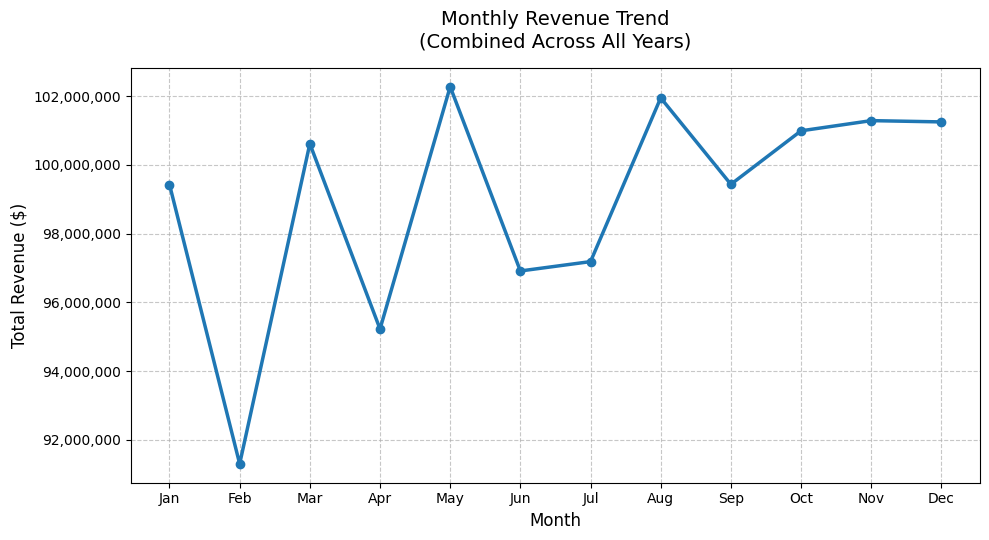

In [53]:
import calendar
# ───────────────────────────────────────────────
# 1. Prepare the data (safe & reliable)
# ───────────────────────────────────────────────
df_new['order_date'] = pd.to_datetime(df_new['order_date'])          # make sure it's datetime

# Extract month number (1 = Jan, 2 = Feb, ..., 12 = Dec)
df_new['month'] = df_new['order_date'].dt.month

# Aggregate TOTAL revenue for each month across ALL years
monthly_trend = (
    df_new.groupby('month')['revenue']
      .sum()
      .reset_index()
)

# Add nice month names (Jan, Feb, ..., Dec) in correct order
monthly_trend['month_name'] = monthly_trend['month'].map(lambda x: calendar.month_abbr[x])

# ───────────────────────────────────────────────
# 2. Plot the Monthly Trend Line Chart
# ───────────────────────────────────────────────
plt.figure(figsize=(10, 5.5))

plt.plot(monthly_trend['month_name'],
         monthly_trend['revenue'],
         marker='o',
         linewidth=2.5,
         color='#1f77b4',
         markersize=6)

plt.title('Monthly Revenue Trend\n(Combined Across All Years)', fontsize=14, pad=15)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Revenue ($)', fontsize=12)

# Grid + formatting
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=0)   # months are short, no need to rotate

# Add comma separator to y-axis
from matplotlib.ticker import FuncFormatter
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.show()

C:\Users\AKIB\AppData\Local\Temp\ipykernel_14944\2577022818.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


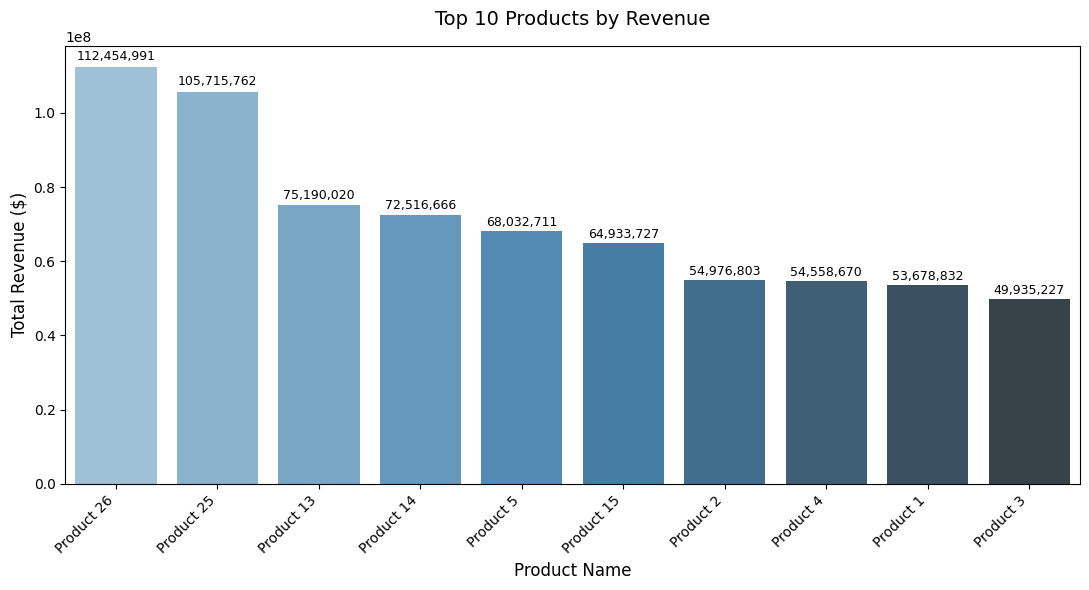

In [54]:
top_n = 10

top_products = df_new.groupby('product_name', as_index=False)['revenue']\
                 .sum()\
                 .sort_values('revenue', ascending=False)\
                 .head(top_n)

plt.figure(figsize=(11, 6))

# Create the bar plot
ax = sns.barplot(
    data=top_products,
    x='product_name',
    y='revenue',
    palette='Blues_d'
)

# Add value labels on top of each bar
for i, bar in enumerate(ax.patches):
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,    # x position (center of bar)
        height + (height * 0.01),             # y position (slightly above bar)
        f'{height:,.0f}',                     # formatted number (with commas)
        ha='center',                          # horizontal alignment
        va='bottom',                          # vertical alignment
        fontsize=9,
        fontweight='medium'
    )

plt.title(f'Top {top_n} Products by Revenue', fontsize=14, pad=15)
plt.xlabel('Product Name', fontsize=12)
plt.ylabel('Total Revenue ($)', fontsize=12)

plt.xticks(rotation=45, ha='right', fontsize=10)
plt.tight_layout()

plt.show()

C:\Users\AKIB\AppData\Local\Temp\ipykernel_14944\796889321.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


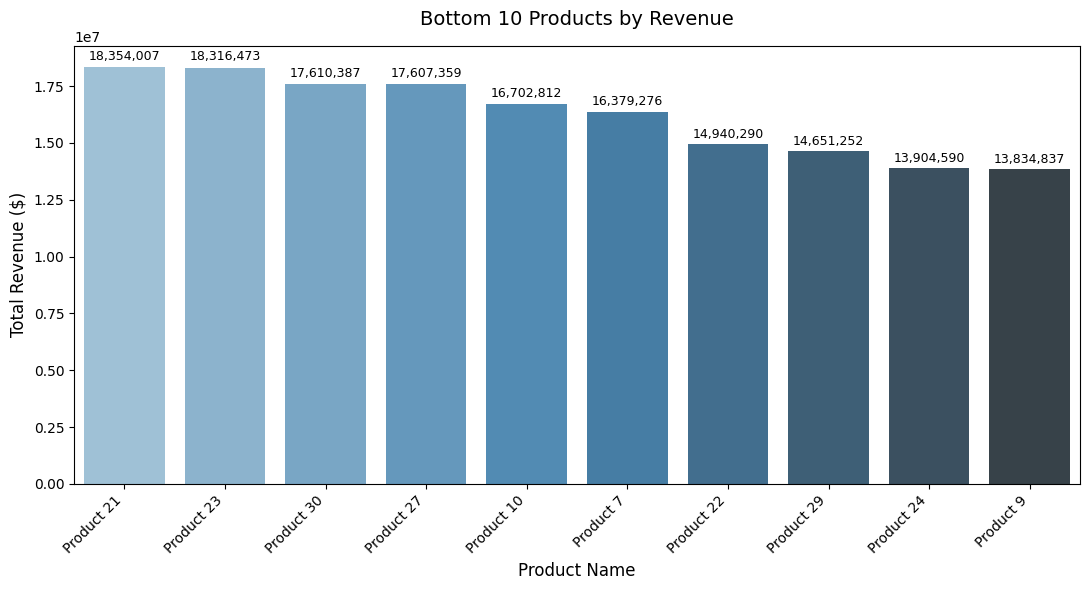

In [55]:
top_n = 10

top_products = df_new.groupby('product_name', as_index=False)['revenue']\
                 .sum()\
                 .sort_values('revenue', ascending=False)\
                 .tail(top_n)

plt.figure(figsize=(11, 6))

# Create the bar plot
ax = sns.barplot(
    data=top_products,
    x='product_name',
    y='revenue',
    palette='Blues_d'
)

# Add value labels on top of each bar
for i, bar in enumerate(ax.patches):
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,    # x position (center of bar)
        height + (height * 0.01),             # y position (slightly above bar)
        f'{height:,.0f}',                     # formatted number (with commas)
        ha='center',                          # horizontal alignment
        va='bottom',                          # vertical alignment
        fontsize=9,
        fontweight='medium'
    )

plt.title(f'Bottom {top_n} Products by Revenue', fontsize=14, pad=15)
plt.xlabel('Product Name', fontsize=12)
plt.ylabel('Total Revenue ($)', fontsize=12)

plt.xticks(rotation=45, ha='right', fontsize=10)
plt.tight_layout()

plt.show()

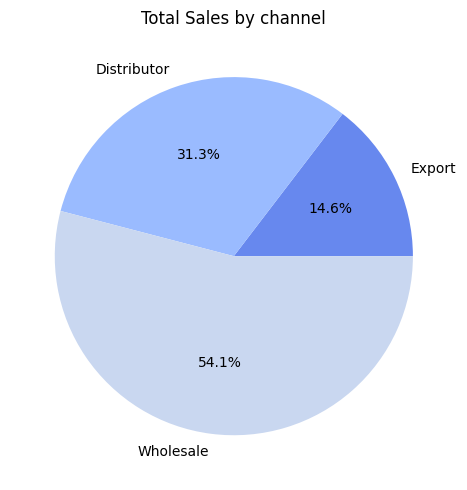

In [56]:
# Sales by Channel 

chan_sales= df.groupby('channel')['revenue'].sum().sort_values(ascending=True)

plt.figure(figsize=(5,5))

plt.pie(
    chan_sales.values,
    labels=chan_sales.index, 
    autopct='%1.1f%%', 
    colors= sns.color_palette('coolwarm')
)

plt.title('Total Sales by channel')
plt.tight_layout()
plt.show()

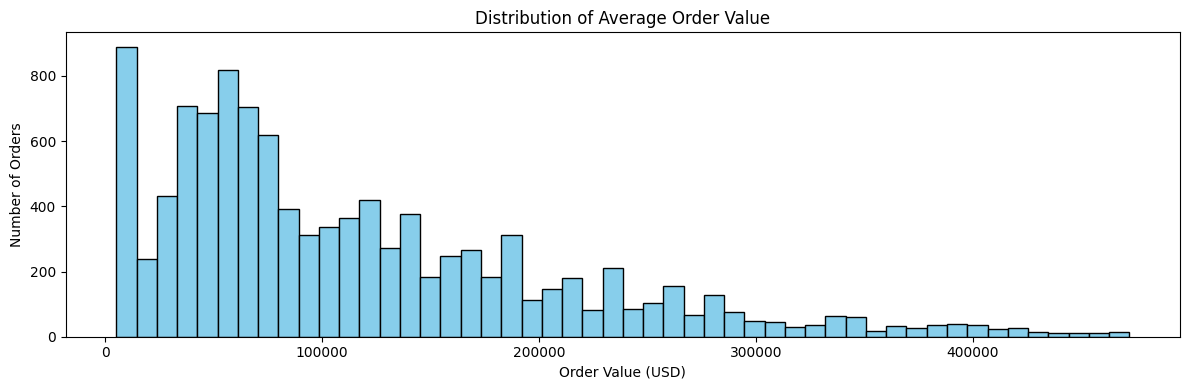

In [57]:
## Average order value (aov) distribution 

aov = df.groupby('order_number')['revenue'].sum()

plt.figure(figsize=(12,4))

plt.hist(
    aov,
    bins=50, 
    color='skyblue', 
    edgecolor='black'
)

plt.title('Distribution of Average Order Value')
plt.xlabel('Order Value (USD)')
plt.ylabel('Number of Orders')

plt.tight_layout()

plt.show()

In [58]:
# Unit Price Distribution per Product 
# Top 10 States by Revenue and Order Count
# Average Profit Margin by Channel
# Top and Bottom 10 customers by revenue
# Customer Segmentation: Revenue vs Profit Margin
# correlation Heatmap

C:\Users\AKIB\AppData\Local\Temp\ipykernel_14944\3079434003.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


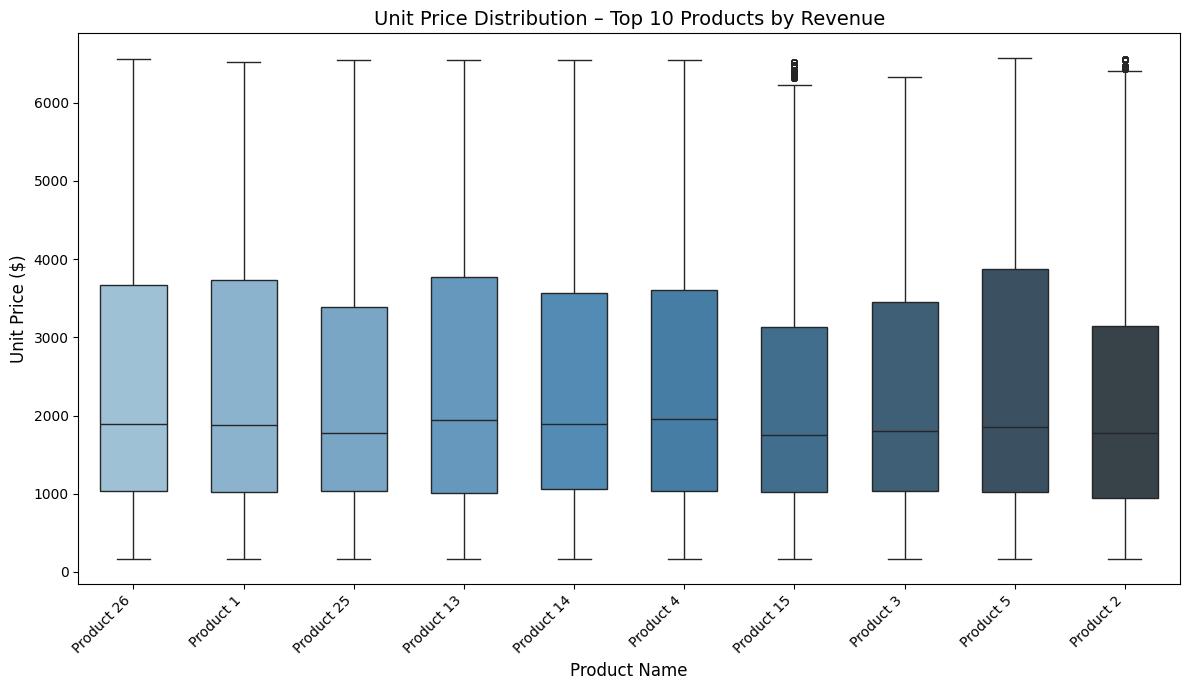

In [59]:
# Get top 10 products by total revenue
top_10_products = (
    df.groupby('product_name')['revenue']
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .index
)

# Filter the dataframe
df_top10 = df[df['product_name'].isin(top_10_products)]

# Plot
plt.figure(figsize=(12, 7))

sns.boxplot(
    data=df_top10,
    x='product_name',
    y='unit_price',
    palette='Blues_d',
    width=0.6,
    fliersize=4,
    whis=1.5
)

plt.title('Unit Price Distribution – Top 10 Products by Revenue', fontsize=14)
plt.xlabel('Product Name', fontsize=12)
plt.ylabel('Unit Price ($)', fontsize=12)

plt.xticks(rotation=45, ha='right', fontsize=10)
plt.tight_layout()
plt.show()

NameError: name 'top10_revenue' is not defined

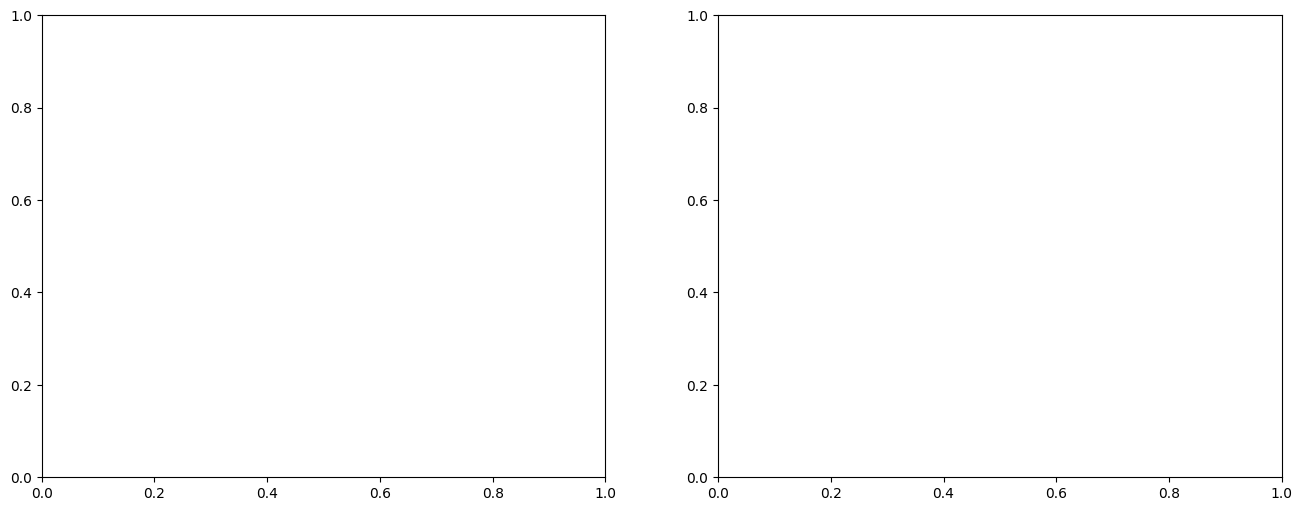

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=False)

# Left: Revenue
sns.barplot(
    data=top10_revenue,
    x='state',
    y='revenue',
    ax=axes[0],
    palette='Blues_d'
)
axes[0].set_title('Top 10 States by Revenue')
axes[0].set_xlabel('State')
axes[0].set_ylabel('Total Revenue ($)')
axes[0].tick_params(axis='x', rotation=45)

# Right: Order Count
sns.barplot(
    data=top10_orders,
    x='state',
    y='order_count',
    ax=axes[1],
    palette='Greens_d'
)
axes[1].set_title('Top 10 States by Order Count')
axes[1].set_xlabel('State')
axes[1].set_ylabel('Order Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

C:\Users\AKIB\AppData\Local\Temp\ipykernel_14944\1913355201.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


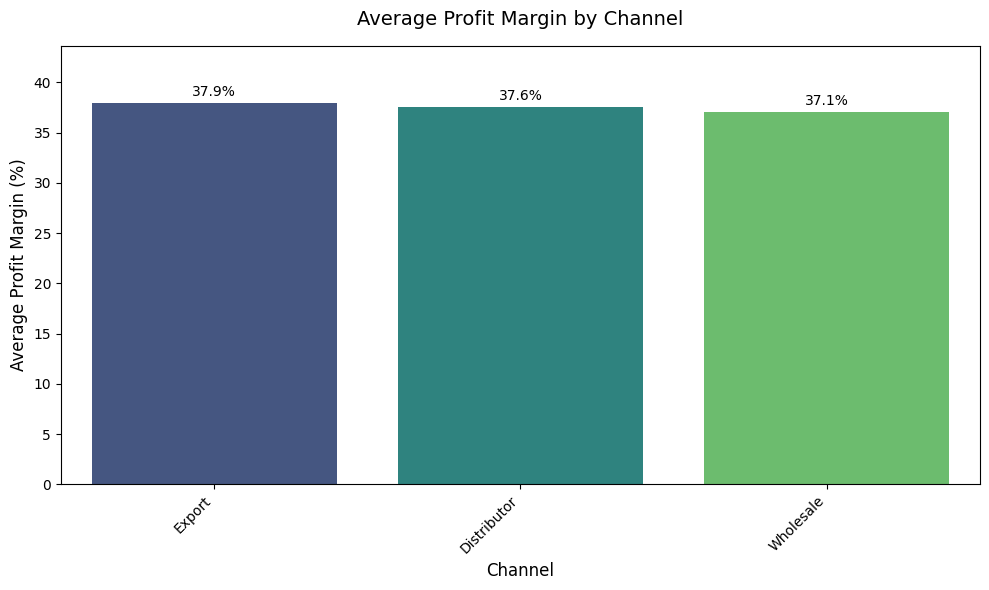

In [61]:
# Calculate average profit margin per channel
avg_margin = (
    df.groupby('channel', as_index=False)['profit_margin_pct']
      .mean()
      .sort_values('profit_margin_pct', ascending=False)
)

# If profit_margin_pct is in decimal form (0.42), multiply by 100
# avg_margin['profit_margin_pct'] = avg_margin['profit_margin_pct'] * 100
# If it's already in percent form (42), leave it as is

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=avg_margin,
    x='channel',
    y='profit_margin_pct',
    palette='viridis'
)

# Add percentage label on top of each bar
for p in ax.patches:
    height = p.get_height()
    # Format: adjust decimals as needed (.1f = one decimal, .0f = no decimal)
    label = f'{height:.1f}%' if height < 10 else f'{height:.1f}%'
    
    ax.text(
        x = p.get_x() + p.get_width() / 2,      # center of bar
        y = height + (height * 0.01),           # slightly above the bar
        s = label,
        ha = 'center',
        va = 'bottom',
        fontsize = 10,
        fontweight = 'medium',
        color = 'black'
    )

plt.title('Average Profit Margin by Channel', fontsize=14, pad=15)
plt.xlabel('Channel', fontsize=12)
plt.ylabel('Average Profit Margin (%)', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)

plt.ylim(0, avg_margin['profit_margin_pct'].max() * 1.15)  # give space for labels

plt.tight_layout()
plt.show()

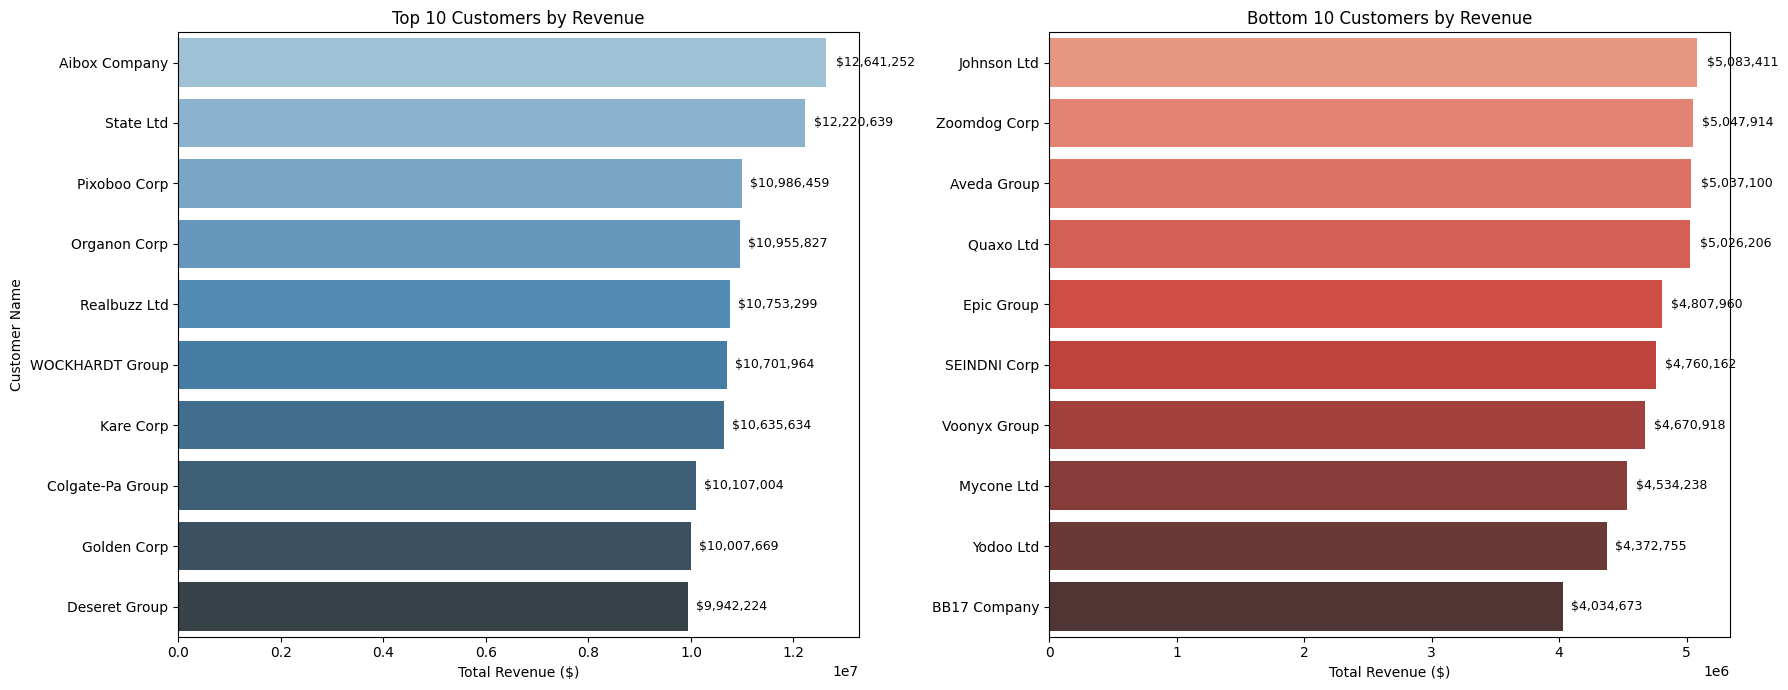

In [62]:
# ─── 1. Calculate total revenue per customer ─────────────────────────────
customer_revenue = (
    df.groupby('customer_names', as_index=False)['revenue']
      .sum()
      .sort_values('revenue', ascending=False)
)

# ─── 2. Top 10 customers ─────────────────────────────────────────────────
top10 = customer_revenue.head(10).copy()
top10['rank'] = range(1, 11)

# ─── 3. Bottom 10 customers ──────────────────────────────────────────────
bottom10 = customer_revenue.tail(10).copy()
bottom10['rank'] = range(1, 11)

# ─── Plot ────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7), sharey=False)

# Top 10
sns.barplot(
    data=top10,
    x='revenue',
    y='customer_names',
    hue='customer_names',         # ← silences FutureWarning
    palette='Blues_d',
    legend=False,
    ax=ax1
)
ax1.set_title('Top 10 Customers by Revenue')
ax1.set_xlabel('Total Revenue ($)')
ax1.set_ylabel('Customer Name')

for i, v in enumerate(top10['revenue']):
    ax1.text(
        x = v * 1.015,            # ← use keyword x=
        y = i,
        s = f'${v:,.0f}',
        va = 'center',
        ha = 'left',
        fontsize = 9
    )

# Bottom 10
sns.barplot(
    data=bottom10,
    x='revenue',
    y='customer_names',
    hue='customer_names',         # ← silences FutureWarning
    palette='Reds_d',
    legend=False,
    ax=ax2
)
ax2.set_title('Bottom 10 Customers by Revenue')
ax2.set_xlabel('Total Revenue ($)')
ax2.set_ylabel('')

for i, v in enumerate(bottom10['revenue']):
    ax2.text(
        x = v * 1.015,
        y = i,
        s = f'${v:,.0f}',
        va = 'center',
        ha = 'left',
        fontsize = 9
    )

plt.tight_layout()
plt.show()

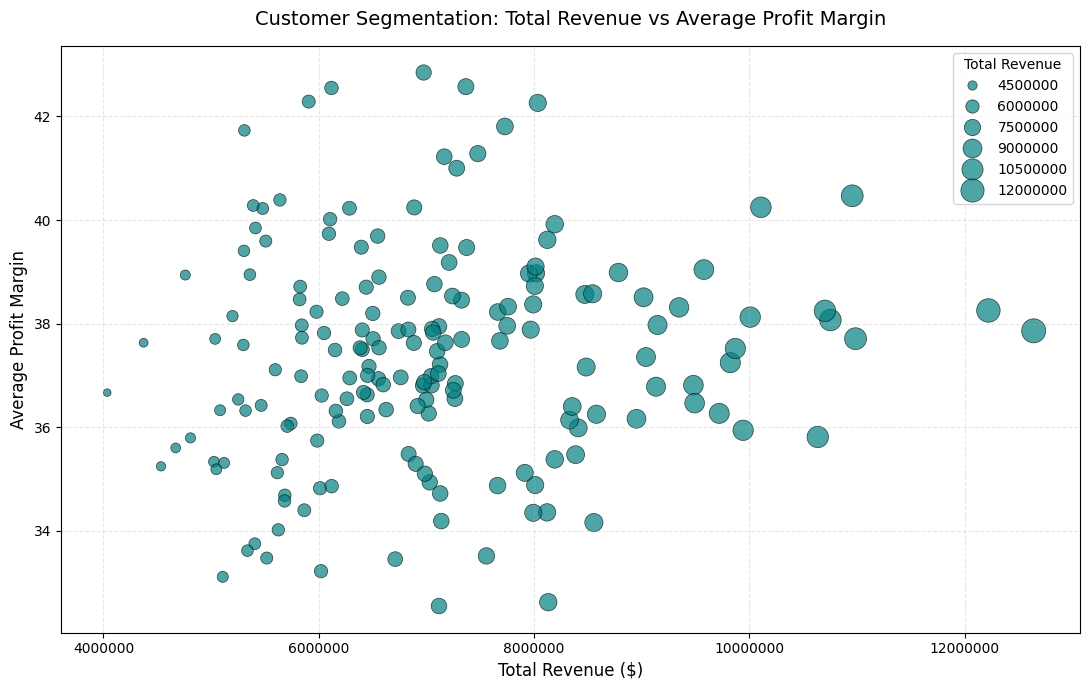

In [63]:
# Aggregate per customer
customer_summary = df.groupby('customer_names').agg({
    'revenue': 'sum',
    'profit_margin_pct': 'mean'          # or 'profit' / 'revenue' if you prefer to recalculate
}).reset_index()

# Optional: rename for clarity
customer_summary = customer_summary.rename(columns={
    'revenue': 'Total Revenue',
    'profit_margin_pct': 'Avg Profit Margin'
})

plt.figure(figsize=(11, 7))

sns.scatterplot(
    data=customer_summary,
    x='Total Revenue',
    y='Avg Profit Margin',
    size='Total Revenue',               # optional: larger dot = higher revenue
    sizes=(30, 300),
    alpha=0.7,
    color='teal',
    edgecolor='black',
    linewidth=0.5
)

plt.title('Customer Segmentation: Total Revenue vs Average Profit Margin', fontsize=14, pad=15)
plt.xlabel('Total Revenue ($)', fontsize=12)
plt.ylabel('Average Profit Margin', fontsize=12)

# Optional: format axes
plt.ticklabel_format(style='plain', axis='x')  # no scientific notation
# plt.xscale('log')   # uncomment if revenue range is very wide (e.g. 10 to 1M+)

plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

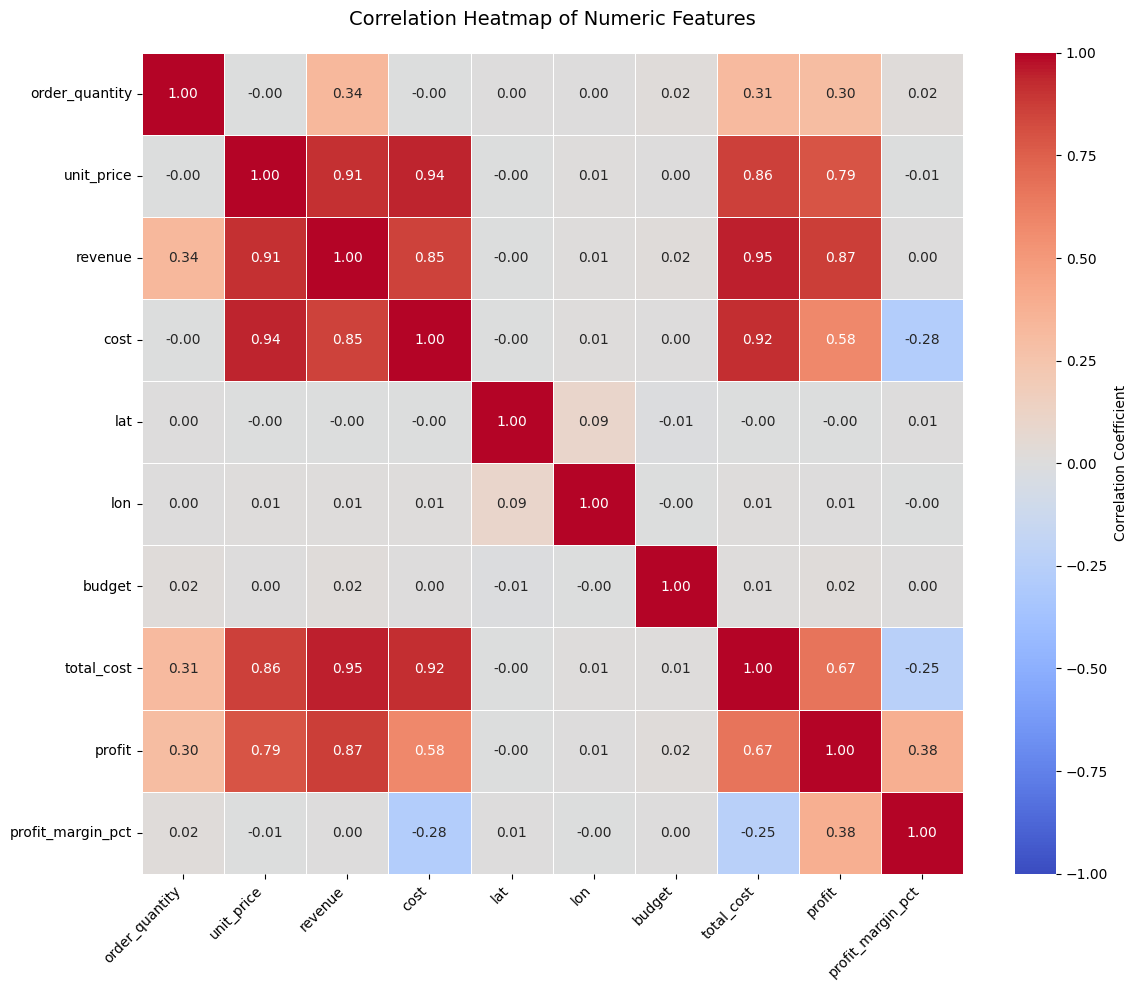

In [64]:
# Select only numeric columns
numeric_df = df.select_dtypes(include=['number', 'float64', 'int64'])

# Calculate correlation matrix
corr = numeric_df.corr()

# Create figure
plt.figure(figsize=(12, 10))

# Heatmap
sns.heatmap(
    corr,
    annot=True,              # show correlation values
    fmt=".2f",               # two decimal places
    cmap='coolwarm',         # red-blue diverging colormap
    vmin=-1, vmax=1,         # correlation range
    center=0,
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'Correlation Coefficient'},
    square=True
)

plt.title('Correlation Heatmap of Numeric Features', fontsize=14, pad=20)
plt.tight_layout()

# Optional: rotate x-labels if many columns / long names
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.show()

In [65]:
df.head()

,order_number,order_date,customer_names,channel,product_name,order_quantity,unit_price,revenue,cost,state,county,state_name,region,lat,lon,budget,total_cost,profit,profit_margin_pct,order_month,month
0,SO - 000225,2014-01-01,Rhynoodle Ltd,Wholesale,Product 27,6,2499.1,14994.6,1824.343,GA,Chatham County,Georgia,South,32.08354,-81.09983,NaN,10946.058,4048.542,27.0,2014-01,2014-01
1,SO - 0003378,2014-01-01,Thoughtmix Ltd,Distributor,Product 20,11,2351.7,25868.7,1269.918,IN,Johnson County,Indiana,Midwest,39.61366,-86.10665,NaN,13969.098,11899.602,46.0,2014-01,2014-01
2,SO - 0005126,2014-01-01,Amerisourc Corp,Wholesale,Product 26,6,978.2,5869.2,684.740,CA,Alameda County,California,West,37.66243,-121.87468,NaN,4108.440,1760.760,30.0,2014-01,2014-01
3,SO - 0005614,2014-01-01,Colgate-Pa Group,Export,Product 7,7,2338.3,16368.1,1028.852,IN,Monroe County,Indiana,Midwest,39.16533,-86.52639,NaN,7201.964,9166.136,56.0,2014-01,2014-01
4,SO - 0005781,2014-01-01,Deseret Group,Wholesale,Product 8,8,2291.4,18331.2,1260.270,CT,Hartford County,Connecticut,Northeast,41.77524,-72.52443,NaN,10082.160,8249.040,45.0,2014-01,2014-01


In [66]:
df.to_csv('file_4.csv')